# 5 Trực quan hoá mối quan hệ đa biến (bằng scatter plot, correlation map, distribution plot, lmplot, clustermap,…) để trả lời xem có thể có mối quan hệ tiềm ẩn nào đó giữa các biến trong tập dữ liệu hay ko, hoặc trực quan hoá không gian dữ liệu nhiều chiều (bằng t-SNE,..) để trả lời xem liệu có quan sát được tính chất cụm của tập dữ liệu đầu vào hay ko 

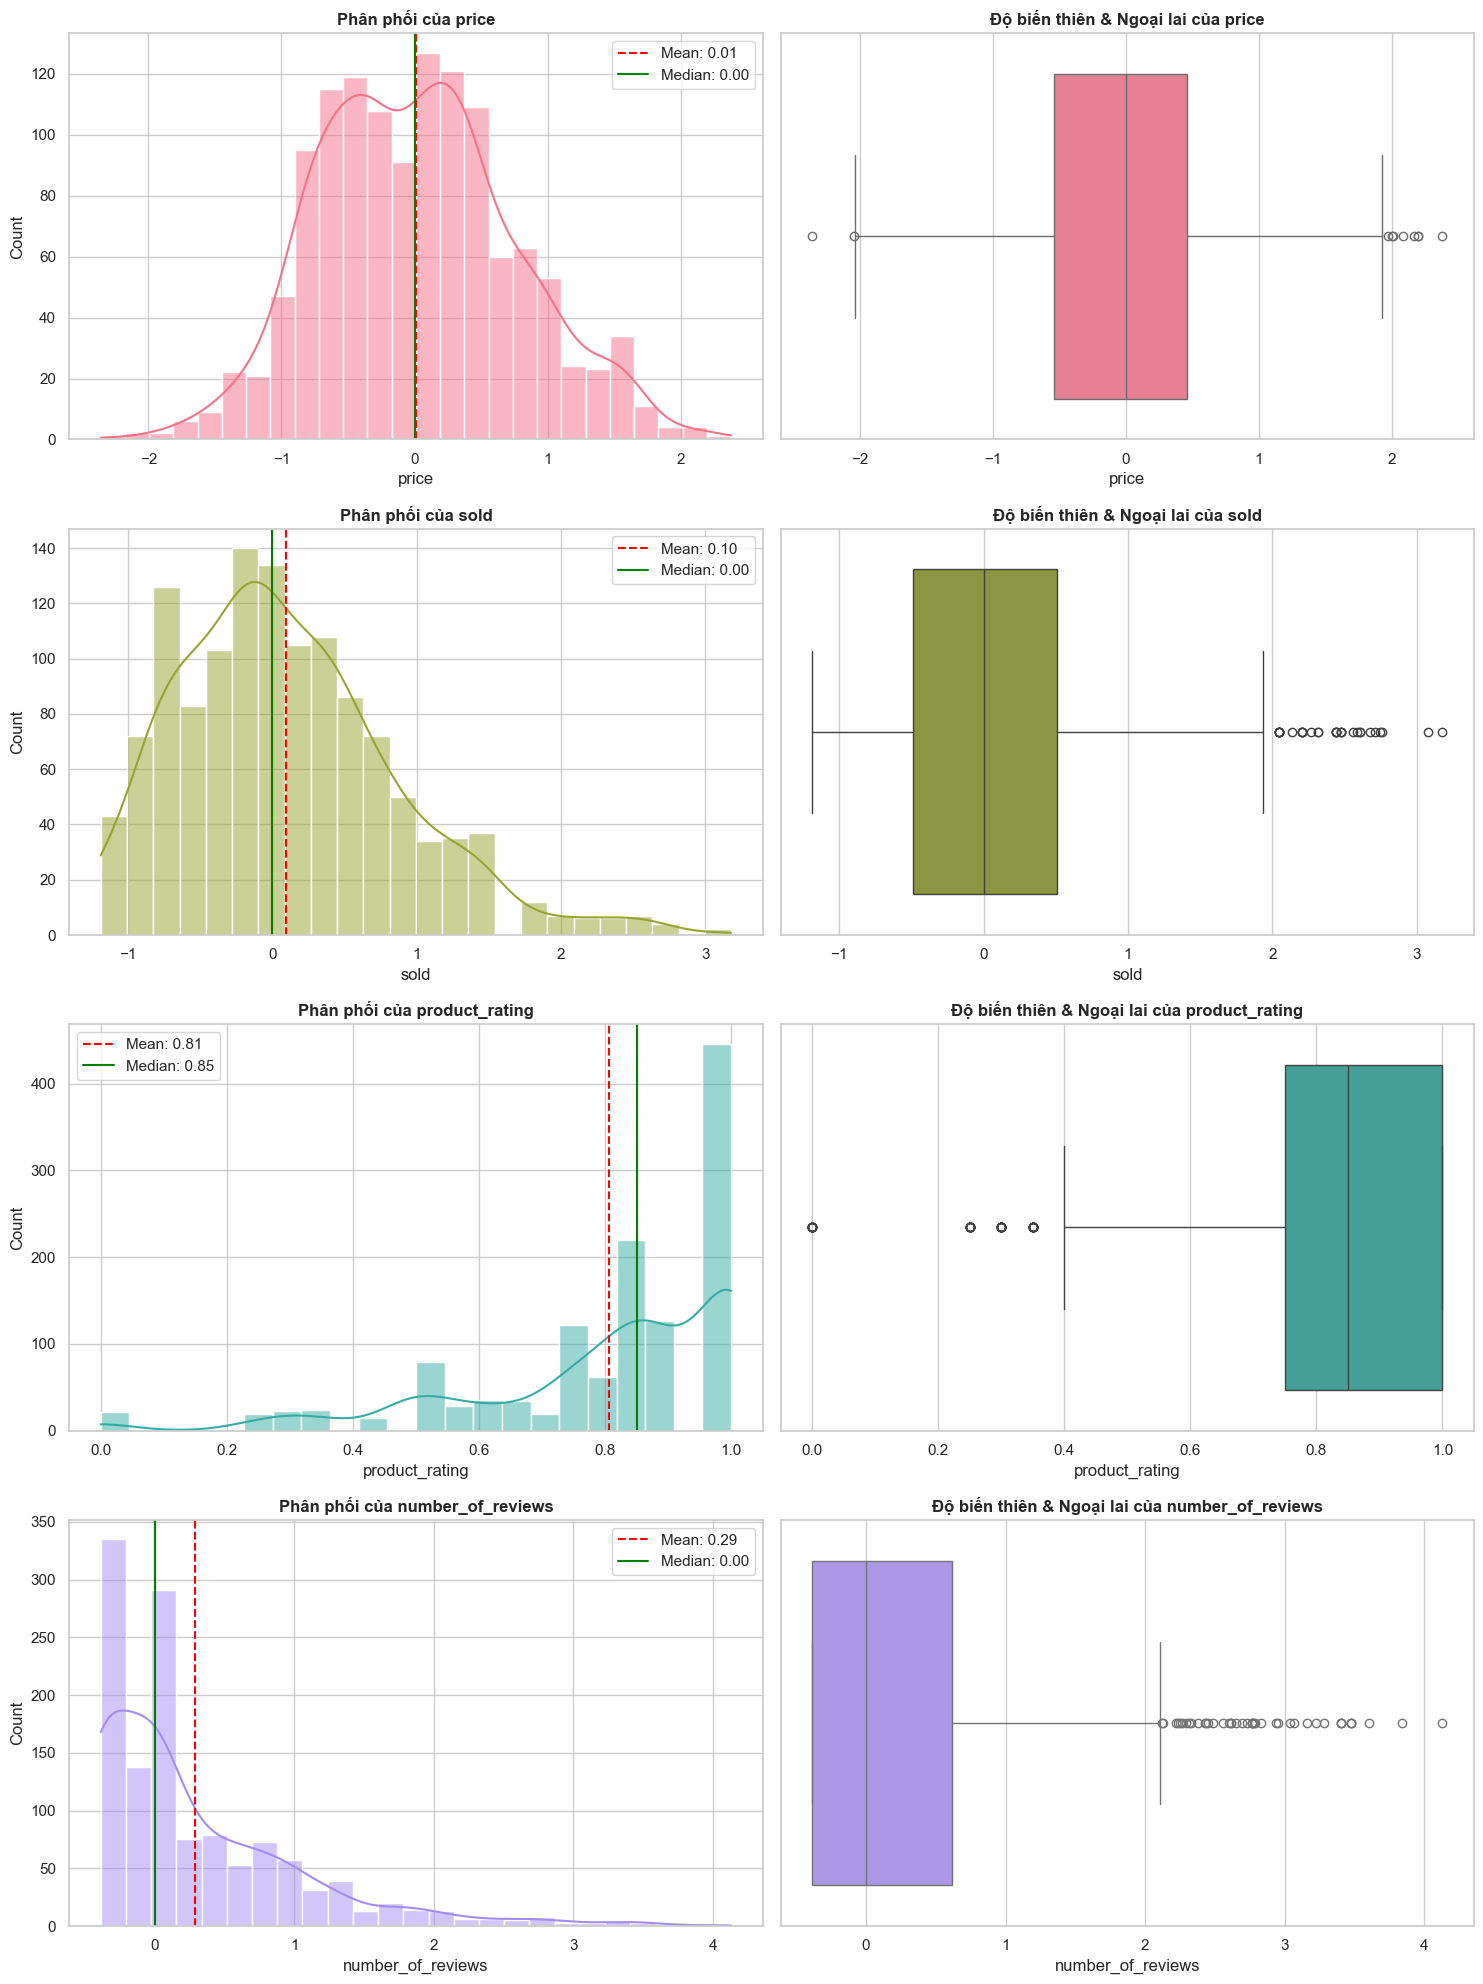

Bảng thống kê mô tả chi tiết:


,count,mean,std,min,25%,50%,75%,max
price,1272.0,0.014797,0.743442,-2.357541,-0.537311,0.00,0.462689,2.378832
sold,1272.0,0.095887,0.763710,-1.186972,-0.488416,0.00,0.511584,3.178896
product_rating,1272.0,0.806014,0.221834,0.000000,0.750000,0.85,1.000000,1.000000
number_of_reviews,1272.0,0.287341,0.757946,-0.386853,-0.386853,0.00,0.613147,4.131727


In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv('clean_encoded.csv')
important_vars = ['price', 'sold', 'product_rating', 'number_of_reviews']

# Thiết lập bảng màu đồng bộ
colors = sns.color_palette("husl", len(important_vars))
color_map = dict(zip(important_vars, colors))

# 2. Tạo Dashboard thống kê đơn biến
fig, axes = plt.subplots(len(important_vars), 2, figsize=(15, 5 * len(important_vars)))

for i, var in enumerate(important_vars):
    # Biểu đồ Histogram + KDE (Phân phối chi tiết)
    sns.histplot(df[var], kde=True, ax=axes[i, 0], color=color_map[var])
    mean_val = df[var].mean()
    median_val = df[var].median()
    
    # Vẽ đường Mean và Median để so sánh độ lệch (skewness)
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i, 0].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[i, 0].set_title(f'Phân phối của {var}', fontweight='bold')
    axes[i, 0].legend()

    # Biểu đồ Boxplot (Xác định ngoại lai và các khoảng tứ phân vị)
    sns.boxplot(x=df[var], ax=axes[i, 1], color=color_map[var])
    axes[i, 1].set_title(f'Độ biến thiên & Ngoại lai của {var}', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Xuất bảng thống kê mô tả (Descriptive Statistics) dạng bảng số liệu
print("Bảng thống kê mô tả chi tiết:")
display(df[important_vars].describe().T)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


df = pd.read_csv("clean_encoded.csv")

df_plot = df.iloc[:, :6].dropna()

columns = df_plot.columns

colors = sns.color_palette("husl", len(columns))
color_map = dict(zip(columns, colors))

print("Color mapping:")
print(color_map)


Color mapping:
{'price': (0.9677975592919913, 0.44127456009157356, 0.5358103155058701), 'discount_percent': (0.7350228985632719, 0.5952719904750953, 0.1944419133847522), 'product_rating': (0.3126890019504329, 0.6928754610296064, 0.1923704830330379), 'number_of_reviews': (0.21044753832183283, 0.6773105080456748, 0.6433941168468681), 'freeship': (0.23299120924703914, 0.639586552066035, 0.9260706093977744), 'sold': (0.9082572436765556, 0.40195790729656516, 0.9576909250290225)}


# Trực quan mối quan hệ giữa các biến với nhau để xem thử có mối quan hệ tiềm ẩn nào giữa các biến với nhau hay không

Ma trận tương quan (Heatmap & Clustermap)
Dùng để trả lời câu hỏi: Các biến có "đi cùng nhau" hay không?

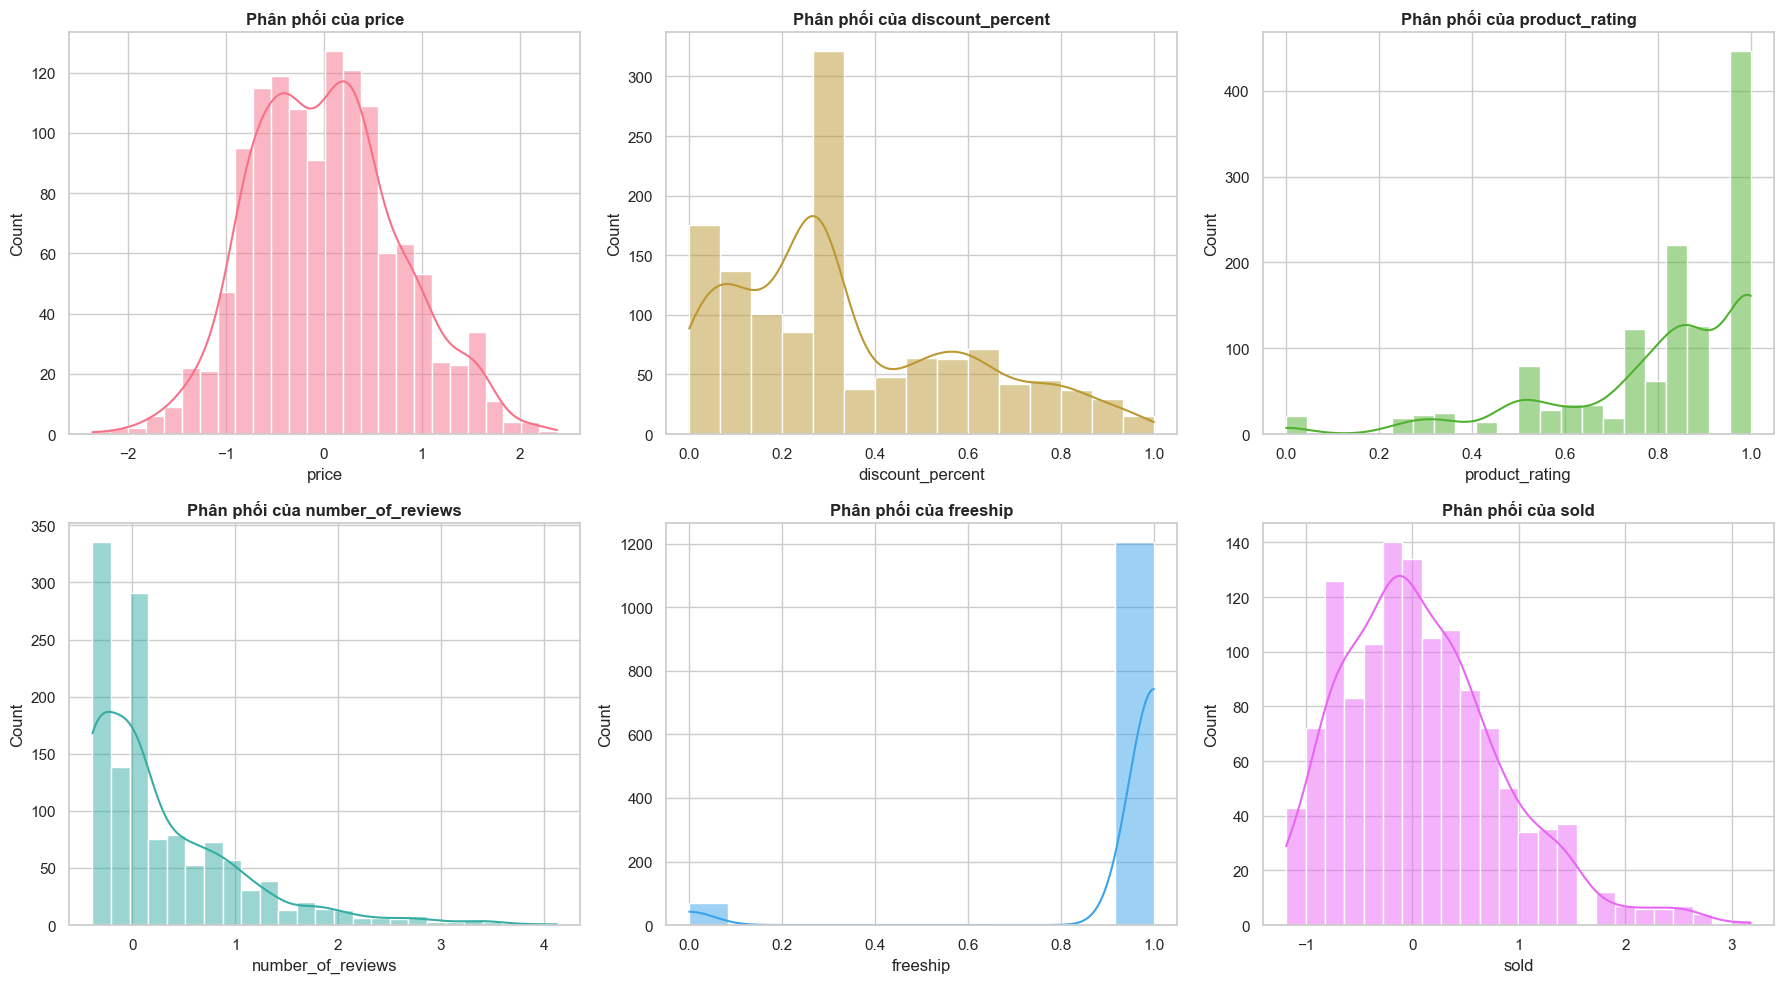

In [ ]:
# 4. DISTRIBUTION PLOT
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(
        df_plot[col],
        kde=True,
        ax=axes[i],
        color=color_map[col]
    )
    axes[i].set_title(f'Phân phối của {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# Kết luận
    1. Giá sản phẩm (price): Biểu đồ phân phối tốt => giá của các sản phẩm tập trung quanh giá trị trung bình

    2. giảm giá (discount_percen): Biểu đồ phân phối không đồng đều, có xu hướng lệch trái, tập trung ở mức phổ biến 20-40%

    3. Đánh giá (product_rating): Biểu đồ phân bố lệch phải, và hầu hết đều có mức đánh giá cao (gần 1) => khó có thể dùng để phân biệt khả năng và tương quan giữa các yếu tố

    4. số lượng đánh giá (number_of_reviews): Biểu đồ lệch trái rất nhiều, đồng thời cũng có nhiều sản phẩn không có hoặc có ít đánh giá, một số ít lại có lượng đánh giá rất cao => Dữ liệu có outliers

    5. freeship: Gần như mọi sản phẩm đều có freeship khi được bán ra => ít có ảnh hưởng 

    6. số lượng đã bán (sold): Biểu đồ phân phối lệch trái, phần lớn sản phẩm có số lượng bán ít, và một số còn lại thì lại được bán rất nhiều
    
=> Sự không đồng đều trong phân phối dữ liệu cho thấy hành vi người dùng trên sàn thương mại điện tử có tính phân hóa cao, trong đó chỉ một số ít sản phẩm chiếm phần lớn lượng tiêu thụ.

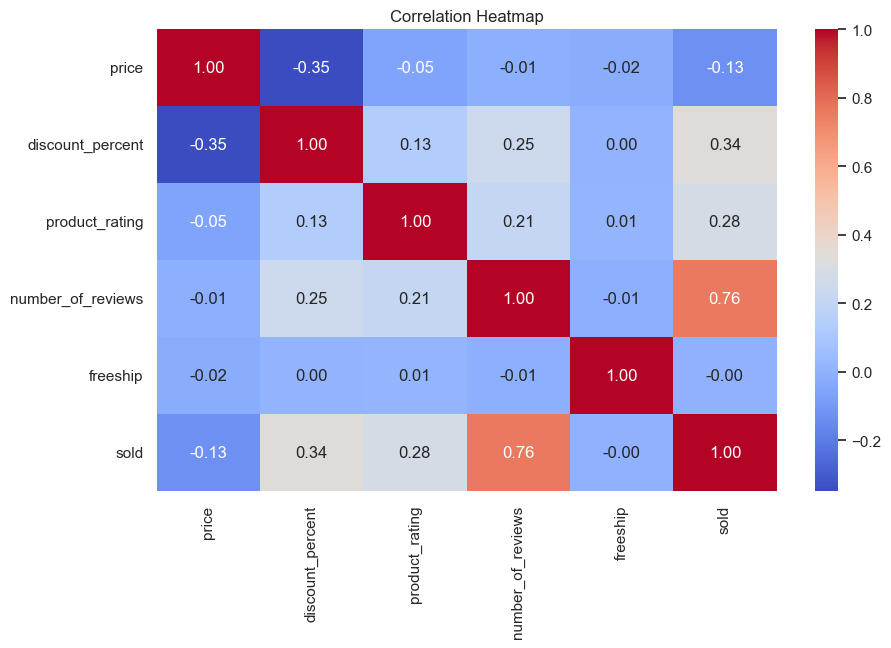

In [51]:
plt.figure(figsize=(10, 6))
corr = df_plot.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Dựa trên biểu đồ correlation heatmap thì ta có thể rút ra nhận xét về mối tương quan giữa các biến như sau:
- 1. number_of_reviews ↔ sold = 0.76
        + Tương quan dương rất mạnh.
        + Khi số lượng review tăng → số lượng bán tăng.
=> Kết luận: Đây là biến quan trọng nhất ảnh hưởng đến sold
- 2. discount_percent ↔ sold = 0.34
        + Tương quan dương mức trung bình
=>Kết luận: Giảm giá có ảnh hưởng đến doanh số nhưng không phải yếu tố quyết định
- 3. product_rating ↔ sold = 0.28
        + Tương quan dương yếu – trung bình
=> Kết luận: Rating có ảnh hưởng nhưng không mạnh
- 4. price ↔ sold = -0.13
        + Tương quan âm rất yếu
=> Kết luận: Giá gần như không ảnh hưởng rõ ràng đến số lượng bán
- 5. freeship ↔ sold ≈ 0
        + Không có tương quan
=>Kết luận:Biến này không có giá trị dự đoán
# Tóm lại:
- Biến number_of_reviews có tương quan mạnh nhất với sold (r = 0.76)
→ Là yếu tố quan trọng nhất trong việc dự đoán doanh số

- Các biến: discount_percent, product_rating
chỉ có ảnh hưởng ở mức trung bình
- Biến price và freeship gần như không có mối quan hệ rõ ràng với sold